<a href="https://colab.research.google.com/github/Geberty/USTspecialTopics2026spring/blob/main/week5gifHW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd

# Google Sheets link provided by the user
google_sheets_link = 'https://docs.google.com/spreadsheets/d/1x4kCepdTTYrNDCj6qs_JjyOAcoT5FsCXyiTLRLCdm4I/edit?usp=sharing'

# Extract the file ID from the link
file_id = google_sheets_link.split('/d/')[1].split('/')[0]

# Construct the CSV export URL
csv_export_url = f'https://docs.google.com/spreadsheets/d/{file_id}/export?format=csv'

try:
    df = pd.read_csv(csv_export_url)
    print("Dataset loaded successfully!")
    print("\nFirst 5 rows of the DataFrame:")
    print(df.head())
    print("\nDataFrame Information:")
    df.info()
except Exception as e:
    print(f"Error loading the dataset: {e}")
    print("Please ensure the Google Sheet is published to the web as CSV or shared appropriately.")

Dataset loaded successfully!

First 5 rows of the DataFrame:
  Unnamed: 0     Gene1     Gene2     Gene3     Gene4      Gene5     Gene6  \
0      Cell1  5.992481  8.637750  9.148508  0.000000   9.749526       NaN   
1      Cell2  6.705927  8.459997       NaN  0.000000   9.613102  8.837886   
2      Cell3  7.630381       NaN       NaN  0.000000   9.486118  8.731500   
3      Cell4  7.067631  8.952405  9.636137  2.034341   9.719746  7.529173   
4      Cell5  5.732078  8.842180       NaN  2.192864  10.138186  7.676739   

      Gene7     Gene8      Gene9  ...   Gene192   Gene193   Gene194   Gene195  \
0  0.000000  4.704148  11.965938  ...  1.172069  2.861306  5.676206  7.064524   
1       NaN  4.354085  11.835529  ...  0.000000       NaN       NaN       NaN   
2       NaN       NaN  12.026917  ...  0.000000  2.729572       NaN  8.092617   
3  0.000000       NaN  12.129077  ...  3.039986  2.623069  5.877711  7.349105   
4  0.777724  4.987332  12.140196  ...       NaN       NaN  5.111780  6.

## Preprocess the data for NN

### Subtask:
Separate features (X) and labels (y) using the 'group' column, perform any necessary encoding or scaling, and split the data into training and testing sets.

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Drop 'Unnamed: 0' column as it's likely an identifier
df_processed = df.drop(columns=['Unnamed: 0'])

# Separate features (X) and labels (y)
X = df_processed.drop(columns=['group'])
y = df_processed['group']

# Impute missing values in features with the mean
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# One-hot encode the target variable 'group'
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y.values.reshape(-1, 1))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y)

print("Data preprocessing complete.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")


Data preprocessing complete.
Shape of X_train: (80, 199)
Shape of y_train: (80, 4)
Shape of X_test: (20, 199)
Shape of y_test: (20, 4)


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the Keras Sequential Model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer
    Dense(64, activation='relu'), # Hidden layer 1
    Dense(y_train.shape[1], activation='softmax') # Output layer (number of classes)
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display the model summary
print("Model Summary:")
model.summary()

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=10, # You can adjust the number of epochs
    batch_size=16, # You can adjust the batch size
    validation_split=0.2, # Use 20% of the training data for validation
    verbose=1
)

print("\nModel training complete.")

Model Summary:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │        25,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,116 (133.27 KB)

 Trainable params: 34,116 (133.27 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - accuracy: 0.3625 - loss: 1.4015 - val_accuracy: 0.4375 - val_loss: 1.2233
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7604 - loss: 0.8648 - val_accuracy: 0.5625 - val_loss: 0.8675
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9729 - loss: 0.4215 - val_accuracy: 0.6875 - val_loss: 0.6351
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 1.0000 - loss: 0.2286 - val_accuracy: 0.8750 - val_loss: 0.4670
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.1206 - val_accuracy: 0.9375 - val_loss: 0.3480
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0731 - val_accuracy: 1.0000 - val_loss: 0.2627
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 1.0000 - loss: 0.0460 - val_accuracy: 1.0000 - val_loss: 0.1986
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.0204 - val_accuracy: 1.0000 - val_loss: 0.1552

In [16]:
from tensorflow.keras.models import Sequential

# Create a new Sequential model that includes all layers up to the penultimate one
# model.layers[:-1] selects all layers except the last (output) layer.
feature_extractor = Sequential(model.layers[:-1])

# Use this feature_extractor model to predict the activations for the test data
penultimate_output_test = feature_extractor.predict(X_test)

print("Shape of penultimate_output_test:", penultimate_output_test.shape)
print("First 5 rows of penultimate_output_test:")
print(penultimate_output_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Shape of penultimate_output_test: (20, 64)
First 5 rows of penultimate_output_test:
[[0.         0.         0.         0.         0.         0.
  0.         0.         2.9919727  0.22766179 0.         0.7241401
  0.         0.99288803 0.         0.         1.340942   0.95393234
  1.8162811  0.7274736  0.56289685 0.         0.10038868 0.5975608
  0.         1.1820205  0.7578146  1.2292284  1.2604666  0.
  0.         2.1842027  0.         0.26060072 2.103141   0.30186194
  0.9249371  0.32970235 0.         0.         1.7115103  0.33955562
  0.         0.3308845  2.2484043  1.9742069  0.         0.
  0.70591044 0.         0.         1.8528287  0.         0.59896296
  0.         1.1993891  0.72209334 0.5375862  0.6854407  1.6272348
  0.         0.         1.5941665  0.        ]
 [0.         0.         0.         0.         2.0975027  0.
  0.34145263 0.         1.5435622  0.         0.11474264 1.0406692
  0.         0.9488575  0.         0.21171138 0.340

## Perform Dimensionality Reduction (PCA) and Plot Classification

### Subtask:
Apply Principal Component Analysis (PCA) to reduce the dimensionality of the penultimate layer's activations to 2 components for visualization, and then plot these components, coloring each data point according to its original 'group' label.

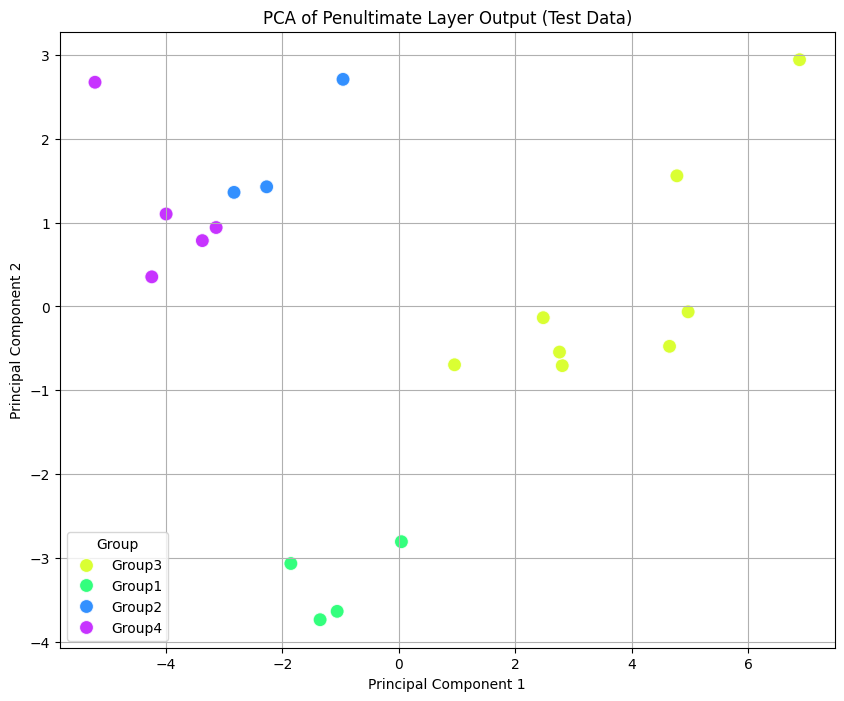

PCA and visualization complete.


In [17]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Initialize PCA to reduce to 2 components
pca = PCA(n_components=2)

# Fit and transform the penultimate layer output for the test data
pca_components = pca.fit_transform(penultimate_output_test)

# Decode the one-hot encoded y_test back to original labels for plotting
y_test_labels = encoder.inverse_transform(y_test)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(data = pca_components, columns = ['PC1', 'PC2'])
pca_df['Group'] = y_test_labels.flatten()

# Plot the PCA components
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', hue='Group', data=pca_df,
    palette=sns.color_palette('hsv', n_colors=len(pca_df['Group'].unique())),
    s=100, alpha=0.8
)
plt.title('PCA of Penultimate Layer Output (Test Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

print("PCA and visualization complete.")

In [26]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import imageio.v2 as imageio # Import imageio
import glob # For listing files
import os # For managing files

# Reinitialize the model to reset its weights
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer
    Dense(64, activation='relu'), # Hidden layer 1
    Dense(y_train.shape[1], activation='softmax') # Output layer (number of classes)
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# List to store filenames of the PCA plots
plot_filenames = []

# Create a directory to save plots if it doesn't exist
output_dir = 'pca_plots_steps'
os.makedirs(output_dir, exist_ok=True)

print("Starting iterative training (step by step) and PCA visualization...")

# Train for 12 steps, one at a time
for step in range(1, 31): # Loop for the first 30 steps
    print(f"\n--- Training Step {step} ---")
    model.fit(
        X_train,
        y_train,
        epochs=1, # Train for 1 epoch, but only process 1 step
        steps_per_epoch=1, # Process only one batch per 'epoch' (which we treat as a step)
        batch_size=16,
        validation_split=0.2,
        verbose=0 # Suppress verbose output for each single step
    )

    # Create a feature extractor model that ends at the penultimate layer
    feature_extractor = Sequential(model.layers[:-1])

    # Get the activations of the penultimate layer for the test data
    penultimate_output_test = feature_extractor.predict(X_test, verbose=0)

    # Initialize PCA to reduce to 2 components
    pca = PCA(n_components=2)

    # Fit and transform the penultimate layer output for the test data
    pca_components = pca.fit_transform(penultimate_output_test)

    # Decode the one-hot encoded y_test back to original labels for plotting
    # Ensure y_test_labels is obtained correctly for each iteration's context
    y_test_labels_decoded = encoder.inverse_transform(y_test).flatten()

    # Create a DataFrame for plotting
    pca_df = pd.DataFrame(data = pca_components, columns = ['PC1', 'PC2'])
    pca_df['Group'] = y_test_labels_decoded

    # Plot the PCA components
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='PC1', y='PC2', hue='Group', data=pca_df,
        palette=sns.color_palette('hsv', n_colors=len(pca_df['Group'].unique())),
        s=100, alpha=0.8
    )
    plt.title(f'PCA of Penultimate Layer Output (Test Data) - Step {step}')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True)

    # Save the plot
    plot_filename = os.path.join(output_dir, f'pca_step_{step:03d}.png')
    plt.savefig(plot_filename)
    plot_filenames.append(plot_filename)
    plt.close() # Close the plot to free up memory

print("\nAll PCA plots saved. Creating GIF...")

# Create GIF from the saved plots
with imageio.get_writer('pca_evolution_steps.gif', mode='I', fps=1) as writer:
    for filename in plot_filenames:
        image = imageio.imread(filename)
        writer.append_data(image)

print("GIF 'pca_evolution_steps.gif' created successfully!")

# Optional: Clean up individual plot files
# for filename in plot_filenames:
#     os.remove(filename)
# os.rmdir(output_dir)
# print("Cleaned up temporary plot files.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting iterative training (step by step) and PCA visualization...

--- Training Step 1 ---

--- Training Step 2 ---

--- Training Step 3 ---

--- Training Step 4 ---

--- Training Step 5 ---

--- Training Step 6 ---

--- Training Step 7 ---

--- Training Step 8 ---

--- Training Step 9 ---

--- Training Step 10 ---

--- Training Step 11 ---

--- Training Step 12 ---

--- Training Step 13 ---

--- Training Step 14 ---

--- Training Step 15 ---

--- Training Step 16 ---

--- Training Step 17 ---

--- Training Step 18 ---

--- Training Step 19 ---

--- Training Step 20 ---

--- Training Step 21 ---

--- Training Step 22 ---

--- Training Step 23 ---

--- Training Step 24 ---

--- Training Step 25 ---

--- Training Step 26 ---

--- Training Step 27 ---

--- Training Step 28 ---

--- Training Step 29 ---

--- Training Step 30 ---

All PCA plots saved. Creating GIF...
GIF 'pca_evolution_steps.gif' created successfully!


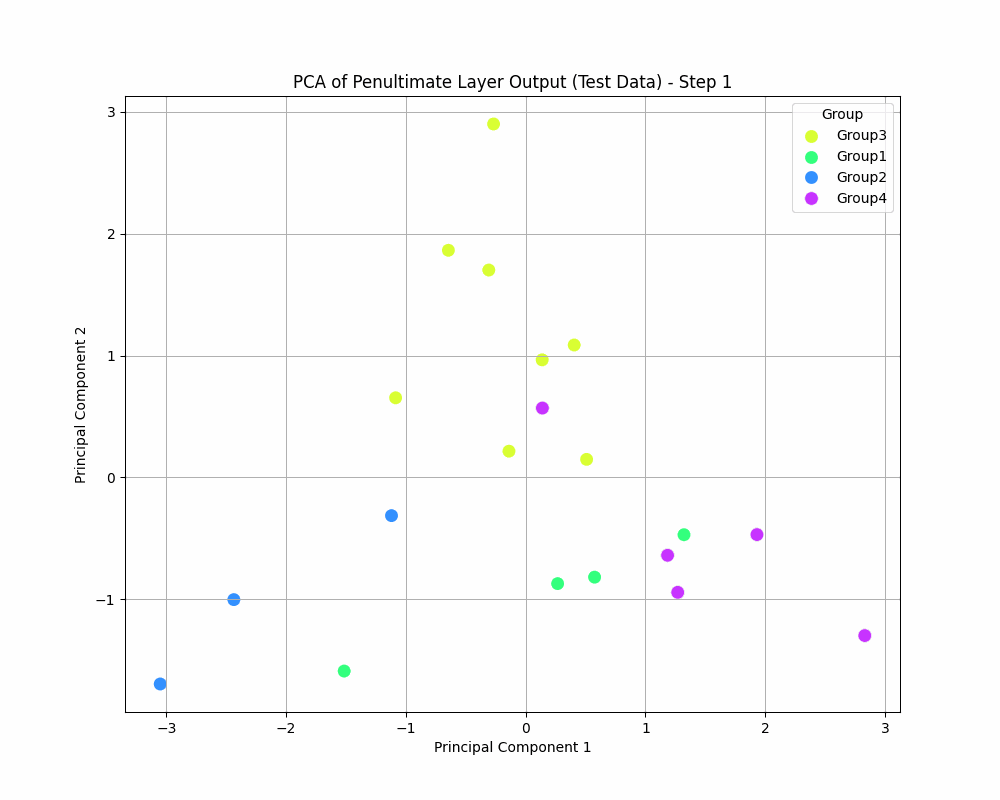

In [27]:
from IPython.display import Image
Image(filename='pca_evolution_steps.gif')

In [28]:
from google.colab import files
files.download('pca_evolution_steps.gif')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>